# Experiment 1 – K-Nearest Neighbors (KNN)

## Mục tiêu
Trong notebook này, ta huấn luyện **K-Nearest Neighbors (KNN)** trên bộ dữ liệu Titanic, 
với **các đặc trưng cơ bản (Exp1)**:
- Không sử dụng Feature Engineering nâng cao
- Chỉ bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu
2. Khám phá dữ liệu (EDA cơ bản)
3. Huấn luyện K-Nearest Neighbors (KNN)
4. Đánh giá mô hình và xuất kết quả

### 1. Khám phá dữ liệu 

In [62]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
sns.set(style="whitegrid")

train = pd.read_csv('/kaggle/input/titanicdatasets/train (1).csv')
test = pd.read_csv('/kaggle/input/titanicdatasets/test (1).csv')

print(train.shape, test.shape)
train.head()


(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Biểu đồ phân bố biến đầu vào và biến đầu ra


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


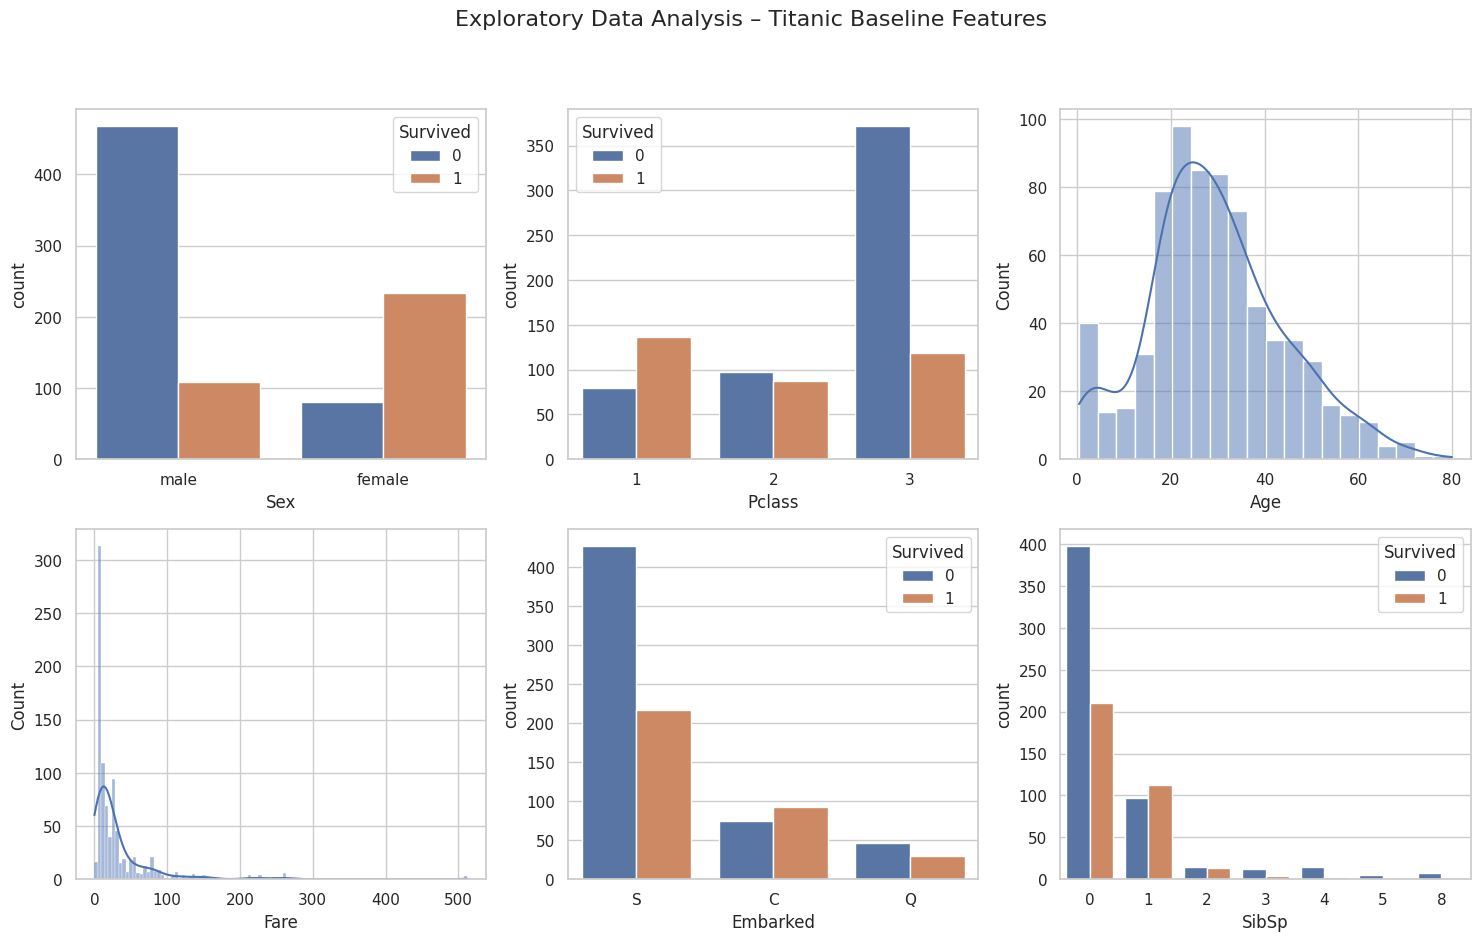

In [63]:
fig, axs = plt.subplots(2, 3, figsize=(18,10))
sns.countplot(x='Sex', hue='Survived', data=train, ax=axs[0,0])
sns.countplot(x='Pclass', hue='Survived', data=train, ax=axs[0,1])
sns.histplot(train['Age'], kde=True, ax=axs[0,2])
sns.histplot(train['Fare'], kde=True, ax=axs[1,0])
sns.countplot(x='Embarked', hue='Survived', data=train, ax=axs[1,1])
sns.countplot(x='SibSp', hue='Survived', data=train, ax=axs[1,2])
plt.suptitle("Exploratory Data Analysis – Titanic Baseline Features", fontsize=16)
plt.show()

### 3. Tiền xử lý dữ liệu

In [64]:
def preprocess_baseline(df):
    df['Sex'] = df['Sex'].map({'male':0, 'female':1})
    df['Embarked'] = df['Embarked'].fillna('S')
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    return df

train_clean = preprocess_baseline(train.copy())
test_clean = preprocess_baseline(test.copy())

X = train_clean[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
                 'Embarked_Q', 'Embarked_S']]
y = train_clean['Survived']
X_test = test_clean[X.columns]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4. Huấn luyện mô hình & đánh giá

In [65]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [66]:
model_name = "K-Nearest Neighbors"

knn = KNeighborsClassifier(n_neighbors=5, weights='distance') 
knn.fit(X, y)

cv_acc = cross_val_score(knn, X, y, cv=5, scoring='accuracy').mean()

print(f"{model_name} CV Accuracy: {cv_acc:.4f}")

K-Nearest Neighbors CV Accuracy: 0.6981


### 5. Đánh giá trực quan 


--- Đánh giá mô hình K-Nearest Neighbors trên tập Validation ---


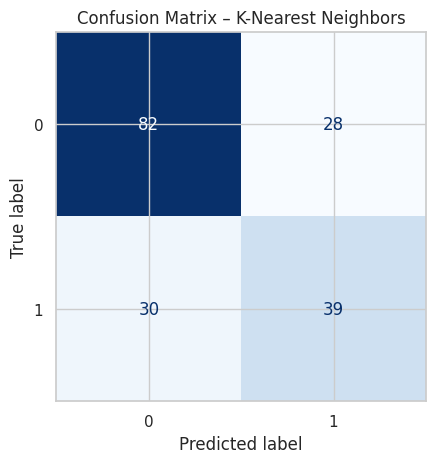

🔍 Classification Report – K-Nearest Neighbors

              precision    recall  f1-score   support

           0     0.7321    0.7455    0.7387       110
           1     0.5821    0.5652    0.5735        69

    accuracy                         0.6760       179
   macro avg     0.6571    0.6553    0.6561       179
weighted avg     0.6743    0.6760    0.6751       179



In [67]:
knn.fit(X_train, y_train)
y_pred_val = knn.predict(X_val)

print(f"\n--- Đánh giá mô hình {model_name} trên tập Validation ---")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix – {model_name}")
plt.show()

# Classification Report
print(f"🔍 Classification Report – {model_name}\n")
print(classification_report(y_val, y_pred_val, digits=4))

### 6. Xuất submission và log kết quả

In [ ]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import os

model_name = "KNN"
public_score = 0.62918 

# === Đánh giá mô hình (Tính lại CV scores) ===
cv_acc = cross_val_score(knn, X, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(knn, X, y, cv=5, scoring='roc_auc').mean()

# --- Hiển thị kết quả in ra (Stdout) ---
print(f"CV Accuracy: {cv_acc:.4f}")
print(f"CV ROC-AUC: {cv_roc:.4f}")

# === Xuất file submission ===
y_pred = knn.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'],
    'Survived': y_pred.astype(int)
})
file_path = f'/kaggle/working/exp1_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved submission: {file_path}")

!cp $file_path /kaggle/working/submission.csv


# === Ghi log kết quả và hiển thị bảng (DataFrame Output) ===
results_path = '/kaggle/working/exp1_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"

# Kiểm tra và tạo header nếu file chưa tồn tại
if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

experiment_name = "Exp1"

# Ghi kết quả vào file log
with open(results_path, 'a') as f:
    # Ghi kết quả của KNN vào log file
    f.write(f"{experiment_name},{model_name},{X.shape[1]},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

# Tải lại DataFrame để hiển thị kết quả
results_df = pd.read_csv(results_path)
display(results_df)

CV Accuracy: 0.6981
CV ROC-AUC: 0.7297
Saved submission: /kaggle/working/exp1_knn_submission.csv


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp1,KNN,8,0.6981,0.7297,0.62918
1,Exp1,KNN,8,0.6981,0.7297,0.62918
2,Exp1,KNN,8,0.6981,0.7297,0.62918


## Kết luận

### Mô hình: K-Nearest Neighbors (KNN)

#### Tập dữ liệu: 
Chỉ sử dụng các đặc trưng gốc (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked)

Không sử dụng: Name, Cabin, Ticket, Deck, Title, FamilySize

#### Kỹ thuật xử lý:

Điền giá trị thiếu (Age, Fare, Embarked)

Mã hóa biến phân loại bằng LabelEncoder

Chia train/test theo cấu trúc competition

#### Kết quả đánh giá:

Accuracy (cross-validation): 0.6981.

Public Kaggle Score: 0.62918

#### Nhận xét:

Mô hình KNN cho thấy hiệu suất ở mức chấp nhận được trên tập baseline, tuy nhiên thấp hơn so với các mô hình tuyến tính (Logistic Regression) hoặc cây (Random Forest) trên cùng tập dữ liệu này.

Điểm Public Score 0.62918 cho thấy mô hình KNN có thể đang gặp khó khăn trong việc xử lý các đặc trưng dạng số (như Age, Fare) mà không cần chuẩn hóa (scaling), hoặc dễ bị ảnh hưởng bởi nhiễu (noise) do khoảng cách Euclidean.

Dự kiến ở Exp2, việc chuẩn hóa dữ liệu số (Feature Scaling) sẽ là bước quan trọng nhất để cải thiện đáng kể hiệu suất của mô hình KNN, bên cạnh việc thêm các đặc trưng từ Feature Engineering.